In [30]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from algorithm_evaluation import evaluate


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Across `CF_fraction` values

In [ ]:

small_networks= ['asia', 'sachs'] #path: small-networks/
medium_networks = ['alarm', 'barley', 'child', 'insurance', 'mildew', 'water'] # path: medium-networks/

all_graphs_paths = [f'small-networks/{graph}.bif' for graph in small_networks] + \
                   [f'medium-networks/{graph}.bif' for graph in medium_networks]
df = pd.DataFrame()

path_prefix= 'algorithm_evaluation/example-graphs/bnlearn/'

CF_fractions = [0, 0.25, 0.5, 0.75, 1]
for CF_fraction in CF_fractions:
    print(f"Evaluating CF_fraction: {CF_fraction}")
    for graph_path in all_graphs_paths:
        print(f"Evaluating graph: {graph_path}")
        df = pd.concat([df, evaluate(
            path_prefix + graph_path,
            confounding_probs=[0.005, 0.015, 0.025, 0.035], # Akbari: [0.05, 0.15, 0.25, 0.35]
            n_simulations=10,
            seed=42,
            verbose=True,
            experiment_set_size=50,
            theta_config=  {
                'CF_fraction': 0.5,
                'W_sizes': [1, 2, 3, 4, 5],
                'Z_sizes': [1, 2, 3, 4, 5],
                'intervention_outcome_distances': [1,2,3,4,5],
            },
            experiment_config={
                'CF_fraction': CF_fraction,
                'W_sizes': [1, 2, 3, 4, 5],
                'Z_sizes': [1, 2, 3, 4, 5],
            }
        )], ignore_index=True)
df.to_csv('algorithm_evaluation/results/17_03__slide_across_CF_fraction.csv', index=False)

Evaluating CF_fraction: 0
Evaluating graph: small-networks/asia.bif
Graph: asia.bif, |V|=8, |A|=50
  p=0.005, sim 10/10: pruned 100.0%
  p=0.015, sim 10/10: pruned 100.0%
  p=0.025, sim 10/10: pruned 100.0%
  p=0.035, sim 10/10: pruned 86.0%
Evaluating graph: small-networks/sachs.bif
Graph: sachs.bif, |V|=11, |A|=50
  p=0.005, sim 10/10: pruned 100.0%
  p=0.015, sim 10/10: pruned 70.0%
  p=0.025, sim 10/10: pruned 84.0%
  p=0.035, sim 10/10: pruned 76.0%
Evaluating graph: medium-networks/alarm.bif
Graph: alarm.bif, |V|=37, |A|=50
  p=0.005, sim 10/10: pruned 80.0%
  p=0.015, sim 10/10: pruned 76.0%
  p=0.025, sim 10/10: pruned 98.0%
  p=0.035, sim 10/10: pruned 94.0%
Evaluating graph: medium-networks/barley.bif
Graph: barley.bif, |V|=48, |A|=50
  p=0.005, sim 10/10: pruned 92.0%
  p=0.015, sim 10/10: pruned 96.0%
  p=0.025, sim 10/10: pruned 94.0%
  p=0.035, sim 10/10: pruned 70.0%
Evaluating graph: medium-networks/child.bif
Graph: child.bif, |V|=20, |A|=50
  p=0.005, sim 10/10: pruned

In [2]:
df = pd.read_csv('algorithm_evaluation/results/17_03__slide_across_CF_fraction.csv')

In [16]:
df

,graph,n_vars,p_conf,sim,n_confounders,query,query_is_cf,min_intervention_outcome_dist,n_R_theta,n_R_theta_star,n_experiments,n_cf_experiments,fraction_cf,n_useless,n_useful,fraction_pruned,id_pruned,blocked_pruned
0,asia.bif,8,0.005,0,1,"Y={'asia', 'either', 'dysp', 'smoke'}, X={'lun...",True,1,1,1,50,0,0.0,50,0,1.00,50,0
1,asia.bif,8,0.005,1,1,"Y={'lung', 'xray', 'either', 'dysp'}, X={'asia...",True,1,1,1,50,0,0.0,50,0,1.00,50,0
2,asia.bif,8,0.005,2,1,"Y={'asia', 'dysp', 'tub'}, X={'lung', 'either'...",True,1,1,1,50,0,0.0,50,0,1.00,50,0
3,asia.bif,8,0.005,3,1,"Y={'tub', 'either', 'xray', 'dysp'}, X={'smoke...",True,1,1,1,50,0,0.0,50,0,1.00,50,0
4,asia.bif,8,0.005,4,1,"Y={'xray'}, X={'asia', 'lung', 'tub', 'either'...",True,1,1,1,50,0,0.0,50,0,1.00,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,water.bif,32,0.035,5,19,"Y={'CBODN_12_45', 'CBODN_12_00', 'CBODD_12_30'...",True,1,11,19,50,50,1.0,0,50,0.00,0,0
1596,water.bif,32,0.035,6,17,"Y={'CNOD_12_30'}, X={'CNON_12_00', 'CKNI_12_00...",True,1,14,17,50,50,1.0,1,49,0.02,0,1
1597,water.bif,32,0.035,7,16,"Y={'CKNI_12_15', 'CNOD_12_15', 'CBODN_12_15', ...",True,1,14,16,50,50,1.0,1,49,0.02,0,1
1598,water.bif,32,0.035,8,20,"Y={'CNOD_12_00', 'CBODD_12_30', 'CKNN_12_45'},...",True,1,20,20,50,50,1.0,0,50,0.00,0,0


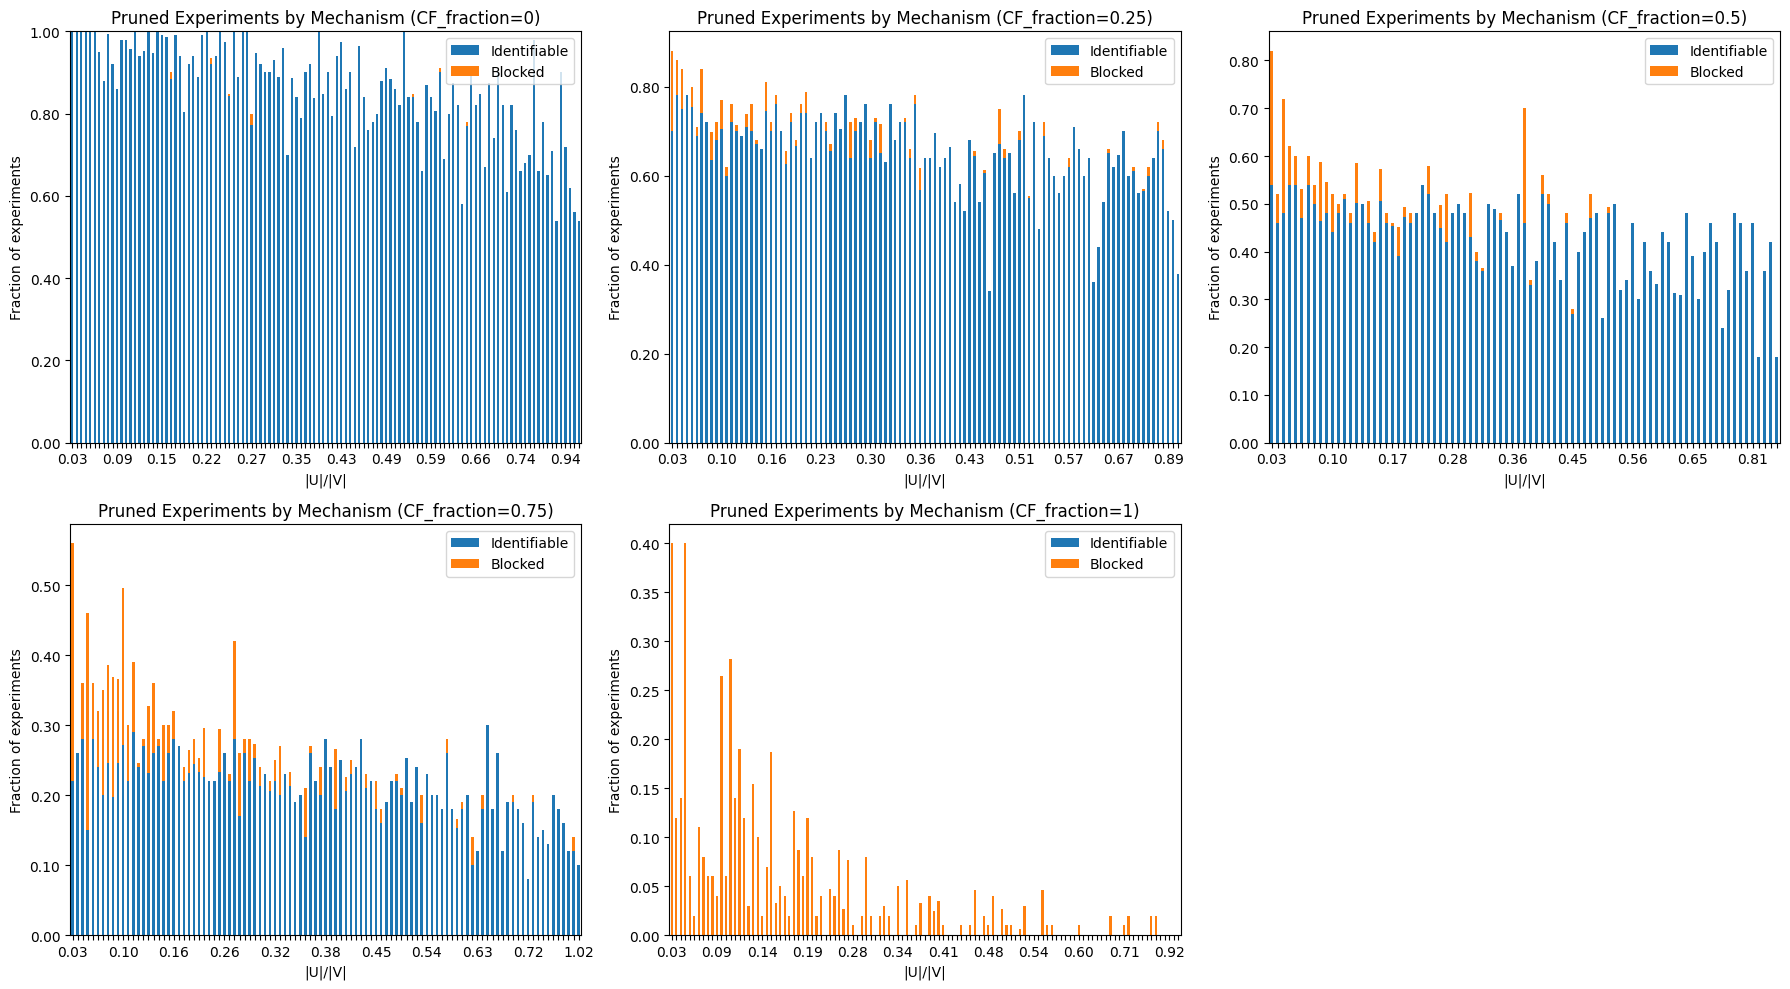

In [3]:
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter

n_rows=2
n_cols=3
# Build figure in this cell to ensure render
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
flat_axes = axes.flatten()

tol = 0.05
source_df = df if not df.empty else df_cf

CF_fractions = [0, 0.25, 0.5, 0.75, 1]

for idx, cf in enumerate(CF_fractions):
    ax = flat_axes[idx]

    mask = source_df["fraction_cf"].between(cf - tol, cf + tol)
    d = source_df.loc[mask]

    if d.empty:
        ax.set_title(f"Pruned Experiments by Mechanism (CF_fraction={cf})\nNo data")
        ax.set_xlabel("|U|/|V|")
        ax.set_ylabel("Fraction of experiments")
        continue

    p = pd.DataFrame({
        "fraction_id": d["id_pruned"] / d["n_experiments"],
        "fraction_blocked": d["blocked_pruned"] / d["n_experiments"],
        "fraction_confounders": d["n_confounders"] / d["n_vars"],
    })

    p = p.groupby("fraction_confounders", as_index=True)[["fraction_id", "fraction_blocked"]].mean()
    p.index = p.index.round(2)

    p.plot(kind="bar", stacked=True, ax=ax)

    ax.set_xlabel("|U|/|V|")
    ax.set_ylabel("Fraction of experiments")
    ax.set_title(f"Pruned Experiments by Mechanism (CF_fraction={cf})")
    ax.legend(["Identifiable", "Blocked"])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
    ax.set_xticklabels(xlabels, rotation=0)

# hide unused panels
for j in range(len(CF_fractions), len(flat_axes)):
    flat_axes[j].set_visible(False)

fig.tight_layout()
plt.show()


## Across `intervention_outcome_distances`

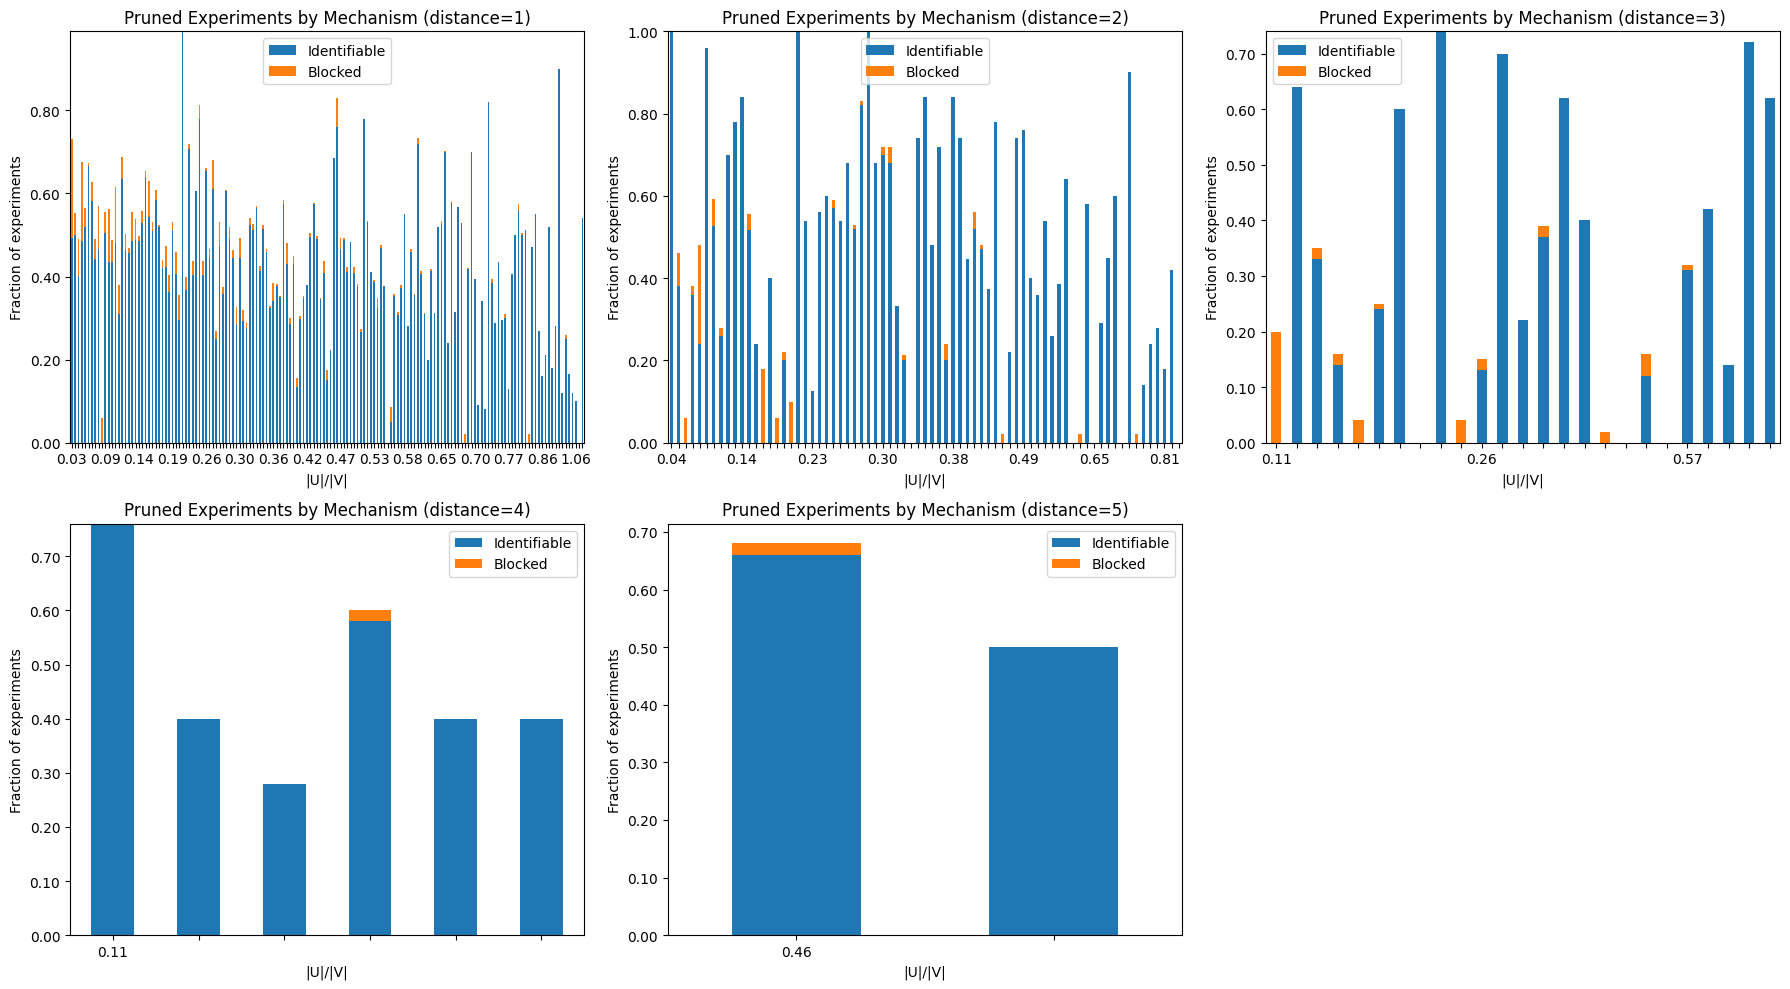

In [5]:
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

n_rows=2
n_cols=3
# Build figure in this cell to ensure render
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
flat_axes = axes.flatten()

source_df = df if not df.empty else df_cf

distances = [1,2,3,4,5]

for idx, dist in enumerate(distances):
    ax = flat_axes[idx]

    mask = source_df["min_intervention_outcome_dist"] == dist
    d = source_df.loc[mask]

    if d.empty:
        ax.set_title(f"Pruned Experiments by Mechanism (distance={dist})\nNo data")
        ax.set_xlabel("|U|/|V|")
        ax.set_ylabel("Fraction of experiments")
        continue

    p = pd.DataFrame({
        "fraction_id": d["id_pruned"] / d["n_experiments"],
        "fraction_blocked": d["blocked_pruned"] / d["n_experiments"],
        "fraction_confounders": d["n_confounders"] / d["n_vars"],
    })

    p = p.groupby("fraction_confounders", as_index=True)[["fraction_id", "fraction_blocked"]].mean()
    p.index = p.index.round(2)

    p.plot(kind="bar", stacked=True, ax=ax)

    ax.set_xlabel("|U|/|V|")
    ax.set_ylabel("Fraction of experiments")
    ax.set_title(f"Pruned Experiments by Mechanism (distance={dist})")
    ax.legend(["Identifiable", "Blocked"])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
    ax.set_xticklabels(xlabels, rotation=0)

# hide unused panels
for j in range(len(distances), len(flat_axes)):
    flat_axes[j].set_visible(False)

fig.tight_layout()
plt.show()

## Different $R^*_\theta$

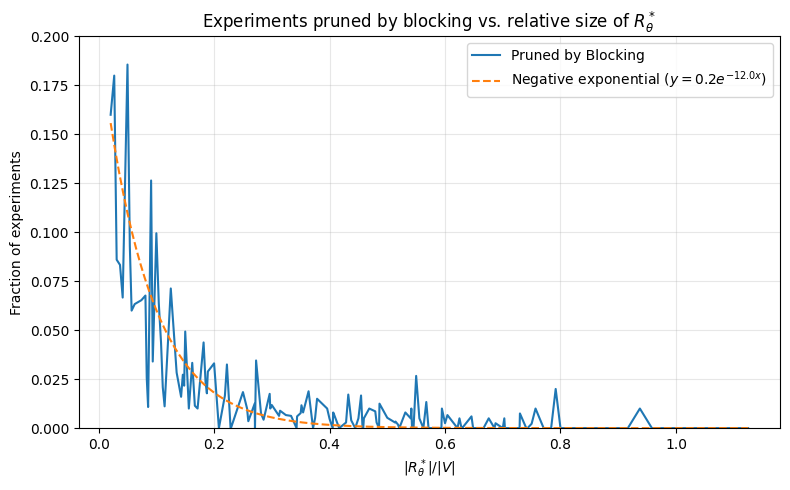

In [29]:
plot_df = (
    df.assign(
        r_star_frac=df["n_R_theta_star"] / df["n_vars"],
        fraction_id=df["id_pruned"] / df["n_experiments"],
        fraction_blocked=df["blocked_pruned"] / df["n_experiments"],
    )
    .groupby("r_star_frac", as_index=False)[["fraction_id", "fraction_blocked"]]
    .mean()
    .sort_values("r_star_frac")
)

plt.figure(figsize=(8, 5))
# plt.plot(plot_df["r_star_frac"], plot_df["fraction_id"], marker="o", label="Identifiable")
plt.plot(plot_df["r_star_frac"], plot_df["fraction_blocked"], label="Pruned by Blocking")

# Negative exponential curve: y = a * exp(-b x)
x_exp = np.linspace(plot_df["r_star_frac"].min(), plot_df["r_star_frac"].max(), 300)
a, b = 0.2, 12.0
y_exp = a * np.exp(-b * x_exp)
plt.plot(x_exp, y_exp, linestyle="--", label=rf"Negative exponential ($y={a}e^{{-{b}x}}$)")

plt.xlabel(r"$|R^*_\theta|/|V|$")
plt.ylabel("Fraction of experiments")
plt.title(r"Experiments pruned by blocking vs. relative size of $R^*_\theta$")
plt.ylim(0, 0.2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()